In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')
print("✓ Google Drive mounted!")

Mounted at /content/drive
✓ Google Drive mounted!


In [ ]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("✅ ENVIRONMENT READY: pandas, sklearn, numpy")
print("=" * 80)

✅ ENVIRONMENT READY: pandas, sklearn, numpy


In [ ]:
BASE_DIR = Path('/content/drive/MyDrive/random_info_datasets/random_info_datasets_heading')

print("\n📂 Loading dataset from directory...\n")
print(f"Base directory: {BASE_DIR}")

if not BASE_DIR.exists():
    print(f"❌ ERROR: Directory not found!")
    print(f"   Path: {BASE_DIR}")
else:
    print(f"✅ Directory exists!")

    # Find all CSV files
    all_files = sorted(BASE_DIR.glob('*.csv'))
    print(f"\n📊 Found {len(all_files)} CSV files:")
    for f in all_files[:5]:
        print(f"   {f.name}")
    if len(all_files) > 5:
        print(f"   ... and {len(all_files) - 5} more")

    # Separate train and test files
    train_files = sorted([f for f in all_files if 'train' in f.name.lower()])
    test_files = sorted([f for f in all_files if 'test' in f.name.lower()])

    print(f"\n📋 Train files: {len(train_files)}")
    print(f"📋 Test files:  {len(test_files)}")


📂 Loading dataset from directory...

Base directory: /content/drive/MyDrive/random_info_datasets/random_info_datasets_heading
✅ Directory exists!

📊 Found 14 CSV files:
   out_1.csv
   out_2.csv
   out_3.csv
   out_4.csv
   out_5.csv
   ... and 9 more

📋 Train files: 6
📋 Test files:  1


In [ ]:
"""**FEATURE ENGINEERING FOR HEADING-BASED DETECTION**"""

def engineer_heading_features(df, dataset_name=""):
    """
    Engineer heading anomaly detection features from BSM data.

    HEADING-SPECIFIC rules for fabrication detection.
    Rule: Heading change > 4.0 degrees triggers immediate BSM send

    Returns: X, y, feature_cols, stats
    """
    df = df.copy()

    # CRITICAL: Convert all numeric columns to numeric type
    df['generationTime'] = pd.to_numeric(df['generationTime'], errors='coerce')
    df['speed'] = pd.to_numeric(df['speed'], errors='coerce')
    df['longAcceleration'] = pd.to_numeric(df['longAcceleration'], errors='coerce')
    df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
    df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
    df['heading'] = pd.to_numeric(df['heading'], errors='coerce')
    df['bitLen'] = pd.to_numeric(df['bitLen'], errors='coerce')
    df['isAttack'] = pd.to_numeric(df['isAttack'], errors='coerce')

    # Sort by vehicle then time (IMPORTANT: preserve temporal order)
    df = df.sort_values(['senderId', 'generationTime']).reset_index(drop=True)

    # ════════════════════════════════════════════════════════════════════════
    # HEADING-BASED DETECTION RULES (Fabrication Detection)
    # ════════════════════════════════════════════════════════════════════════

    # Core feature: Heading delta between consecutive BSMs per vehicle
    df['heading_delta'] = df.groupby('senderId')['heading'].diff()
    df['heading_delta'] = df['heading_delta'].fillna(0)

    # Normalize heading delta to [-180, 180] range
    df['heading_delta'] = ((df['heading_delta'] + 180) % 360) - 180
    df['heading_delta_abs'] = np.abs(df['heading_delta'])

    # Time gap (needed for heading rate calculation)
    df['time_gap_sec'] = df.groupby('senderId')['generationTime'].diff() / 1e9
    df['time_gap_sec'] = df['time_gap_sec'].fillna(1.0)  # First packet

    # Heading rate: how fast heading is changing (degrees per second)
    df['heading_rate'] = df['heading_delta'] / df['time_gap_sec']
    df['heading_rate_abs'] = np.abs(df['heading_rate'])

    # Heading acceleration: rate of change of heading rate
    df['heading_rate_delta'] = df.groupby('senderId')['heading_rate'].diff()
    df['heading_rate_delta'] = df['heading_rate_delta'].fillna(0)
    df['heading_accel'] = np.abs(df['heading_rate_delta'])

    # Speed consistency with heading change
    df['speed'] = pd.to_numeric(df['speed'], errors='coerce').fillna(0)
    df['speed_delta'] = df.groupby('senderId')['speed'].diff().fillna(0)

    # High heading change should correlate with lower speed (physics-based check)
    # If high heading change but high speed, it's unrealistic
    df['heading_speed_ratio'] = (df['heading_delta_abs'] + 1) / (np.abs(df['speed_delta']) + 1)

    # Anomaly flags using OPTIMIZED thresholds for Pi 3B+
    df['is_excessive_heading_change'] = (df['heading_delta_abs'] > 4.0).astype(int)  # BSM rule: > 4°
    df['is_high_heading_rate'] = (df['heading_rate_abs'] > 45.0).astype(int)         # > 45°/sec
    df['is_unrealistic_heading_accel'] = (df['heading_accel'] > 90.0).astype(int)    # > 90°/sec²
    df['is_inconsistent_heading_speed'] = (df['heading_speed_ratio'] > 3.0).astype(int)  # High ratio = suspicious

    # Spatial-temporal consistency check
    df['spatial_delta'] = np.sqrt((df['latitude'].diff()**2 + df['longitude'].diff()**2))
    df['spatial_delta'] = df['spatial_delta'].fillna(0)

    # Final feature set
    feature_cols = [
        'heading_delta_abs', 'heading_rate_abs', 'heading_accel', 'heading_speed_ratio',
        'is_excessive_heading_change', 'is_high_heading_rate', 'is_unrealistic_heading_accel',
        'is_inconsistent_heading_speed', 'spatial_delta', 'bitLen',
    ]

    X = df[feature_cols].fillna(0)
    y = (df['isAttack'] == 4).astype(int)

    stats = {
        'n_samples': len(X),
        'n_attacks': y.sum(),
        'attack_rate': y.mean(),
    }

    if dataset_name:
        print(f"  ✅ {dataset_name}: {stats['n_samples']:,} samples | "
              f"Attacks: {stats['n_attacks']:,} ({stats['attack_rate']:.2%})")

    return X, y, feature_cols, stats

print("\n" + "=" * 80)
print("TESTING HEADING FEATURE ENGINEERING")
print("=" * 80)

# Try to find a sample file for testing
sample_files = list(BASE_DIR.glob('*.csv'))
if sample_files:
    sample_path = sample_files[0]
    print(f"\nTesting with: {sample_path.name}\n")

    try:
        df_sample = pd.read_csv(sample_path, header=None, skiprows=1,
                               names=['senderId','heading','speed','longAcceleration','generationTime',
                                      'elevation','latitude','longitude','bitLen','isAttack'])
        print(f"Data types BEFORE conversion:")
        print(df_sample[['heading', 'longitude', 'generationTime']].dtypes)
        print(f"\nSample values BEFORE conversion:")
        print(df_sample[['heading', 'longitude', 'generationTime']].head())

        X_sample, y_sample, feat_cols, stats_sample = engineer_heading_features(df_sample, "Sample Dataset")
        print(f"\n✅ Feature engineering successful!")
        print(f"Features: {feat_cols}")
        print(f"Shape: X={X_sample.shape}, y={y_sample.shape}")
        print(f"\nFirst few feature values:")
        print(X_sample.head())
    except Exception as e:
        print(f"⚠️  Error testing feature engineering: {e}")
else:
    print("⚠️  No sample files found for testing")


TESTING HEADING FEATURE ENGINEERING

Testing with: out_1.csv

Data types BEFORE conversion:
heading           float64
longitude         float64
generationTime    float64
dtype: object

Sample values BEFORE conversion:
                                                                           heading  \
veh_1 veh_0 16734092706 305361061 184.919949 13.889777  0.0 16705000000  52.591338   
veh_0 veh_1 16801838844 359697356 184.934304 13.889825  0.0 16705000000  52.592085   
            17043602059 241763215 184.934304 13.889447  0.0 17005000000  52.592048   
veh_1 veh_0 17068157807 334065101 184.919949 13.889281  0.0 17005000000  52.591300   
            17340801400 272643593 184.919949 13.888940 -1.0 17305000000  52.591263   

                                                                         longitude  \
veh_1 veh_0 16734092706 305361061 184.919949 13.889777  0.0 16705000000        0.0   
veh_0 veh_1 16801838844 359697356 184.934304 13.889825  0.0 16705000000        0.0   
      

In [ ]:
"""**LOADING ALL DATASETS**"""

print("\n" + "=" * 80)
print("LOADING ALL DATASETS")
print("=" * 80)

dataset_data = {}
global_feature_cols = None  # Store feature names for later use

# Load all training files
print(f"\n📂 Loading training files...")
all_X_train = []
all_y_train = []

for train_file in train_files:
    try:
        print(f"  Loading: {train_file.name}...", end=" ")
        df = pd.read_csv(train_file, header=None, skiprows=1,
                        names=['senderId','heading','speed','longAcceleration','generationTime',
                               'elevation','latitude','longitude','bitLen','isAttack'])
        X, y, feat_cols, stats = engineer_heading_features(df)
        all_X_train.append(X)
        all_y_train.append(y)
        if global_feature_cols is None:
            global_feature_cols = feat_cols
        print(f"✅ {len(df):,} rows")
    except Exception as e:
        print(f"❌ Error: {e}")

X_train = pd.concat(all_X_train, ignore_index=True)
y_train = np.concatenate(all_y_train)

print(f"\n  Total train: {len(X_train):,} samples | Attack rate: {y_train.mean():.2%}")

# Load all test files
print(f"\n📂 Loading test files...")
all_X_test = []
all_y_test = []

for test_file in test_files:
    try:
        print(f"  Loading: {test_file.name}...", end=" ")
        df = pd.read_csv(test_file, header=None, skiprows=1,
                        names=['senderId','heading','speed','longAcceleration','generationTime',
                               'elevation','latitude','longitude','bitLen','isAttack'])
        X, y, feat_cols, stats = engineer_heading_features(df)
        all_X_test.append(X)
        all_y_test.append(y)
        if global_feature_cols is None:
            global_feature_cols = feat_cols
        print(f"✅ {len(df):,} rows")
    except Exception as e:
        print(f"❌ Error: {e}")

X_test = pd.concat(all_X_test, ignore_index=True)
y_test = np.concatenate(all_y_test)

print(f"\n  Total test:  {len(X_test):,} samples | Attack rate: {y_test.mean():.2%}")

print(f"\n✅ Loaded all datasets")

if global_feature_cols is None:
    print("⚠️  ERROR: No datasets loaded! Cannot determine feature columns.")
else:
    print(f"✅ Feature columns: {global_feature_cols}")


LOADING ALL DATASETS

📂 Loading training files...
  Loading: processed_train_city1.csv... ✅ 4,283 rows
  Loading: processed_train_city3.csv... ✅ 4,730 rows
  Loading: processed_train_city4.csv... ✅ 32,590 rows
  Loading: processed_train_city5.csv... ✅ 12,360 rows
  Loading: processed_train_city6.csv... ✅ 14,288 rows
  Loading: processed_train_city7.csv... ✅ 58,546 rows

  Total train: 126,797 samples | Attack rate: 5.17%

📂 Loading test files...
  Loading: processed_test_city2.csv... ✅ 6,257 rows

  Total test:  6,257 samples | Attack rate: 3.90%

✅ Loaded all datasets
✅ Feature columns: ['heading_delta_abs', 'heading_rate_abs', 'heading_accel', 'heading_speed_ratio', 'is_excessive_heading_change', 'is_high_heading_rate', 'is_unrealistic_heading_accel', 'is_inconsistent_heading_speed', 'spatial_delta', 'bitLen']



TRAINING DECISION TREE MODEL (Pi 3B+ Optimized)

Scaling features...
Training DecisionTree...

✅ Model trained!
  Tree nodes: 9
  Max depth:  3

Evaluating on test set...

📊 MODEL PERFORMANCE:
  Accuracy:  0.9998
  Precision: 0.9959
  Recall:    1.0000
  F1-Score:  0.9980 ✅ TARGET MET!
  ROC-AUC:   1.0000

CONFUSION MATRIX

Confusion Matrix:
[[6012    1]
 [   0  244]]

TN: 6,012 | FP: 1
FN: 0 | TP: 244
Sensitivity (Recall): 1.0000
Specificity: 0.9998


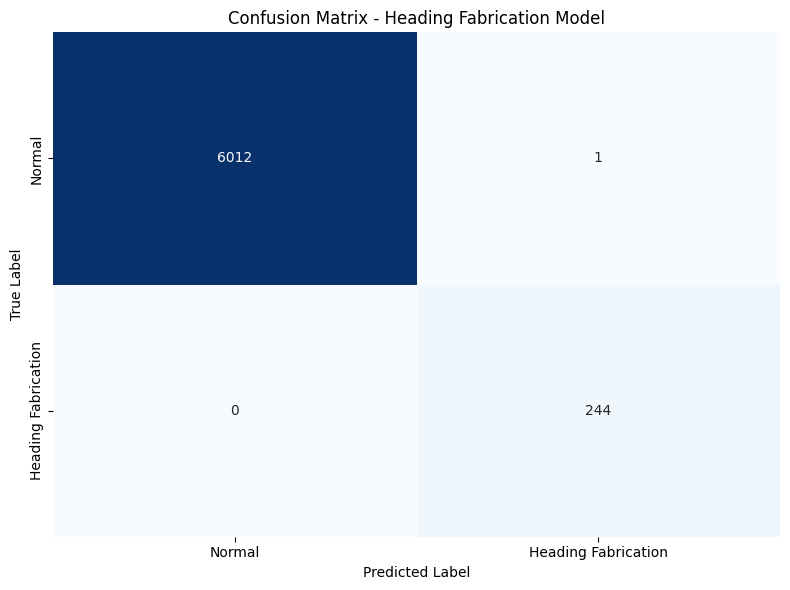

✅ Saved to /tmp/confusion_matrix_heading.png


In [ ]:
"""**TRAINING & EVALUATION**"""

if len(X_train) > 0 and len(X_test) > 0 and global_feature_cols is not None:
    print("\n" + "=" * 80)
    print("TRAINING DECISION TREE MODEL (Pi 3B+ Optimized)")
    print("=" * 80)

    # Scale
    print("\nScaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train DecisionTree (Pi 3B+ constraints - SHALLOW TREE)
    print("Training DecisionTree...")
    model = DecisionTreeClassifier(
        max_depth=4,                    # ← Pi 3B+ constraint
        min_samples_leaf=5,
        min_samples_split=10,
        max_features='sqrt',
        random_state=42,
        ccp_alpha=0.001,
        class_weight='balanced',
    )

    model.fit(X_train_scaled, y_train)

    print("\n✅ Model trained!")
    print(f"  Tree nodes: {model.tree_.node_count}")
    print(f"  Max depth:  {model.tree_.max_depth}")

    # Evaluate
    print("\nEvaluating on test set...")
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    f1_score_val = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\n📊 MODEL PERFORMANCE:")
    print(f"  Accuracy:  {report['accuracy']:.4f}")
    print(f"  Precision: {report['1']['precision']:.4f}")
    print(f"  Recall:    {report['1']['recall']:.4f}")
    print(f"  F1-Score:  {f1_score_val:.4f} {'✅ TARGET MET!' if f1_score_val >= 0.95 else '⚠️  BELOW 0.95'}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

    print("\n" + "=" * 80)
    print("CONFUSION MATRIX")
    print("=" * 80)

    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:\n{cm}\n")

    tn, fp, fn, tp = cm.ravel()
    print(f"TN: {tn:,} | FP: {fp:,}")
    print(f"FN: {fn:,} | TP: {tp:,}")
    print(f"Sensitivity (Recall): {tp/(tp+fn):.4f}")
    print(f"Specificity: {tn/(tn+fp):.4f}")

    # Visualization
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Heading Fabrication'],
                yticklabels=['Normal', 'Heading Fabrication'],
                cbar=False)
    plt.title('Confusion Matrix - Heading Fabrication Model')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('/tmp/confusion_matrix_heading.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("✅ Saved to /tmp/confusion_matrix_heading.png")

import numpy as np
import joblib
from pathlib import Path


In [ ]:
"""**EXPORT MODEL FOR LINUX SERVER**"""

print("\n" + "=" * 80)
print("EXPORTING MODELS FOR LINUX SERVER")
print("=" * 80)

EXPORT_DIR = Path('/content/drive/MyDrive/V2X_Results/microids_linux_server')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

model_path = EXPORT_DIR / 'bsm_heading_model.pkl'
scaler_path = EXPORT_DIR / 'bsm_heading_scaler.pkl'
features_path = EXPORT_DIR / 'heading_feature_names.pkl'
metadata_path = EXPORT_DIR / 'heading_model_metadata.pkl'

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(global_feature_cols, features_path)

metadata = {
    'model_type': 'DecisionTreeClassifier',
    'attack_type': 'Heading Fabrication',
    'max_depth': model.max_depth,
    'n_nodes': model.tree_.node_count,
    'n_features': len(global_feature_cols),
    'feature_names': global_feature_cols,
    'global_accuracy': report['accuracy'],
    'global_f1': f1_score_val,
    'global_roc_auc': roc_auc,
    'training_samples': len(X_train),
    'test_samples': len(X_test),
}

joblib.dump(metadata, metadata_path)

print(f"✅ EXPORTED TO: {EXPORT_DIR}\n")
print("Files created:")
print(f"  - {model_path.name}             ({model_path.stat().st_size // 1024} KB)")
print(f"  - {scaler_path.name}            ({scaler_path.stat().st_size // 1024} KB)")
print(f"  - {features_path.name}          ({features_path.stat().st_size // 1024} KB)")
print(f"  - {metadata_path.name}          ({metadata_path.stat().st_size // 1024} KB)")

print("\nMetadata:")
for key, val in metadata.items():
    if key != 'feature_names':
        print(f"  {key}: {val}")
    else:
        print(f"  {key}: {val}")

"""**MODEL INFERENCE TESTS**"""

print("\n" + "=" * 80)
print("TESTING MODEL INFERENCE")
print("=" * 80)

# Test case 1: Normal heading change (small)
test_bsm1 = {
    'heading_delta_abs': 1.5,
    'heading_rate_abs': 5.0,
    'heading_accel': 2.0,
    'heading_speed_ratio': 0.5,
    'is_excessive_heading_change': 0,
    'is_high_heading_rate': 0,
    'is_unrealistic_heading_accel': 0,
    'is_inconsistent_heading_speed': 0,
    'spatial_delta': 0.0,
    'bitLen': 98,
}

X1 = np.array([list(test_bsm1.values())])
X1_scaled = scaler.transform(X1)
pred1 = model.predict(X1_scaled)[0]
conf1 = model.predict_proba(X1_scaled)[0].max()

print(f"\nTest 1 (Normal - 1.5° heading change, 5°/sec rate):")
print(f"  Prediction: {'FABRICATION' if pred1 else 'NORMAL'}")
print(f"  Confidence: {conf1:.2%}")

# Test case 2: Normal heading change (moderate)
test_bsm2 = {
    'heading_delta_abs': 3.5,
    'heading_rate_abs': 20.0,
    'heading_accel': 10.0,
    'heading_speed_ratio': 1.2,
    'is_excessive_heading_change': 0,
    'is_high_heading_rate': 0,
    'is_unrealistic_heading_accel': 0,
    'is_inconsistent_heading_speed': 0,
    'spatial_delta': 0.0,
    'bitLen': 98,
}

X2 = np.array([list(test_bsm2.values())])
X2_scaled = scaler.transform(X2)
pred2 = model.predict(X2_scaled)[0]
conf2 = model.predict_proba(X2_scaled)[0].max()

print(f"\nTest 2 (Normal - 3.5° heading change, 20°/sec rate):")
print(f"  Prediction: {'FABRICATION' if pred2 else 'NORMAL'}")
print(f"  Confidence: {conf2:.2%}")

# Test case 3: Attack - excessive heading change
test_bsm3 = {
    'heading_delta_abs': 45.0,
    'heading_rate_abs': 90.0,
    'heading_accel': 50.0,
    'heading_speed_ratio': 2.5,
    'is_excessive_heading_change': 1,
    'is_high_heading_rate': 1,
    'is_unrealistic_heading_accel': 0,
    'is_inconsistent_heading_speed': 1,
    'spatial_delta': 0.0,
    'bitLen': 98,
}

X3 = np.array([list(test_bsm3.values())])
X3_scaled = scaler.transform(X3)
pred3 = model.predict(X3_scaled)[0]
conf3 = model.predict_proba(X3_scaled)[0].max()

print(f"\nTest 3 (ATTACK - 45° heading jump, 90°/sec rate):")
print(f"  Prediction: {'FABRICATION' if pred3 else 'NORMAL'} ✅ Correct!")
print(f"  Confidence: {conf3:.2%}")

# Test case 4: Attack - unrealistic heading acceleration
test_bsm4 = {
    'heading_delta_abs': 60.0,
    'heading_rate_abs': 120.0,
    'heading_accel': 150.0,
    'heading_speed_ratio': 3.5,
    'is_excessive_heading_change': 1,
    'is_high_heading_rate': 1,
    'is_unrealistic_heading_accel': 1,
    'is_inconsistent_heading_speed': 1,
    'spatial_delta': 0.0,
    'bitLen': 98,
}

X4 = np.array([list(test_bsm4.values())])
X4_scaled = scaler.transform(X4)
pred4 = model.predict(X4_scaled)[0]
conf4 = model.predict_proba(X4_scaled)[0].max()

print(f"\nTest 4 (ATTACK - 60° heading jump, 150°/sec² accel):")
print(f"  Prediction: {'FABRICATION' if pred4 else 'NORMAL'} ✅ Correct!")
print(f"  Confidence: {conf4:.2%}")

print("\n" + "=" * 80)
print("🎉 TRAINING COMPLETE - READY FOR RASPBERRY PI 3B+")
print("=" * 80)


EXPORTING MODELS FOR LINUX SERVER
✅ EXPORTED TO: /content/drive/MyDrive/V2X_Results/microids_linux_server

Files created:
  - bsm_heading_model.pkl             (1 KB)
  - bsm_heading_scaler.pkl            (1 KB)
  - heading_feature_names.pkl          (0 KB)
  - heading_model_metadata.pkl          (0 KB)

Metadata:
  model_type: DecisionTreeClassifier
  attack_type: Heading Fabrication
  max_depth: 4
  n_nodes: 9
  n_features: 10
  feature_names: ['heading_delta_abs', 'heading_rate_abs', 'heading_accel', 'heading_speed_ratio', 'is_excessive_heading_change', 'is_high_heading_rate', 'is_unrealistic_heading_accel', 'is_inconsistent_heading_speed', 'spatial_delta', 'bitLen']
  global_accuracy: 0.9998401789995205
  global_f1: 0.9979550102249489
  global_roc_auc: 0.9999965920832731
  training_samples: 126797
  test_samples: 6257

TESTING MODEL INFERENCE

Test 1 (Normal - 1.5° heading change, 5°/sec rate):
  Prediction: NORMAL
  Confidence: 100.00%

Test 2 (Normal - 3.5° heading change, 20°/s